In [11]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from extraccion import extraer_todo
from limpieza import ejecutar_limpieza
from normalizacion import ejecutar_normalizacion
from enriquecimiento import ejecutar_enriquecimiento
from reglas_negocio import ejecutar_reglas_negocio
from pca import ejecutar_pca

#pa ejecutar el todos los pasos
datos          = extraer_todo()
limpios        = ejecutar_limpieza(datos['ventas'], datos['inventario'])
normalizados   = ejecutar_normalizacion(limpios['ventas'], limpios['inventario'], datos['perfiles'])
df_enriquecido = ejecutar_enriquecimiento(normalizados['ventas'], normalizados['perfiles'])
df_reglas      = ejecutar_reglas_negocio(df_enriquecido)
df_final       = ejecutar_pca(df_reglas)

Paso 1 EXTRACCION
 Conectando a la db del mysql ahuevo -_-
[mysql] 7500 registros de ventas_historicas.
Conectando a la db de mongo yupii -_-
[mongodb] 1,500 perfiles.
[csv] leyendo ahora el ../data\inventario.csv...
[csv] 840 filas | nulos: 90 | duplicados: 40
[txt] Parseando ../data\logs_servidor.txt con regex
[txt] 2,500 lineas parseadas | Errores de formato: 0
[xml] Parseando ../data\catalogos.xml
[xml] 42 subcategorias en 7 categorias.
[xlsx] leyendo ahora ../data\metas_anuales.xlsx
[xlsx] 24 registros | Columnas: ['Region', 'Trimestre', 'Meta_Ventas_MXN', 'Meta_Clientes_Nuevos', 'Meta_Ticket_Promedio', 'KPI_Conversion_%', 'KPI_Retencion_%', 'Presupuesto_Marketing']
[api] Consultando tipos de cambio en https://api.exchangerate-api.com/v4/latest/USD


c:\Users\Camic.CAMI\Desktop\devora_proyecto_lap\src\extraccion.py:36: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



[api] 8 tipos de cambio
[scraping] Parseando tabla HTML de precios competencia
[scraping] 25 precios de competencia extraidos
EXTRACCION COMPLETA
  ventas          ->  7,500 registros  |  5 columnas
  perfiles        ->  1,500 registros  |  11 columnas
  inventario      ->    840 registros  |  9 columnas
  logs            ->  2,500 registros  |  8 columnas
  catalogos       ->     42 registros  |  4 columnas
  metas           ->     24 registros  |  8 columnas
  tipo_cambio     ->      8 registros  |  2 columnas
  competencia     ->     25 registros  |  4 columnas
Paso 2 LIMPIEZA
Registros antes de limpiar: 7,500
Duplicados eliminados: 0
Registros con monto invalido eliminados: 0
Registros despues de limpiar: 7,500
Filas antes de limpiar: 840
Nulos encontrados:
    - categoria: 26 nulos
    - marca: 20 nulos
    - precio_unitario: 15 nulos
    - stock: 20 nulos
    - proveedor: 9 nulos

Filas eliminadas por nulos: 81
Filas eliminadas por duplicados: 34
Filas despues de limpiar: 725
Pas

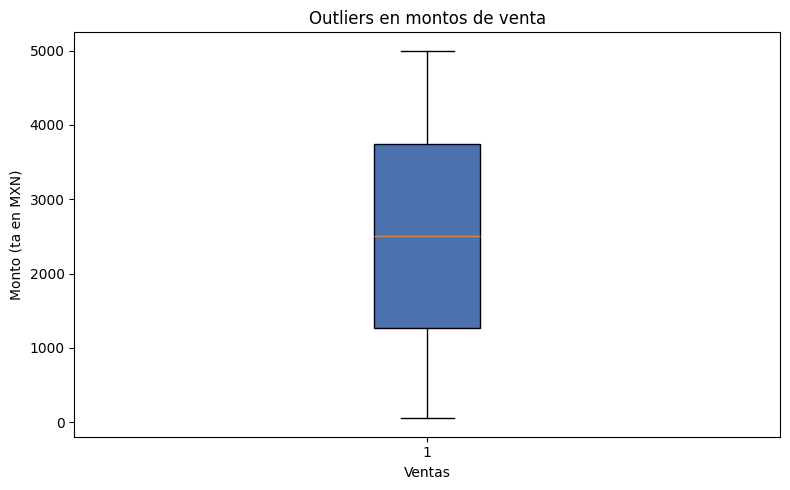

In [12]:
#boxplot para detectar outliers en los montos de venta
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df_final['monto'].dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', color='black'))
ax.set_title('Outliers en montos de venta')
ax.set_ylabel('Monto (ta en MXN)')
ax.set_xlabel('Ventas')
plt.tight_layout()
plt.show()

In [13]:
#sankey para mostrar flujo de usuarios desde la web hasta la compra
df_logs = datos['logs']
etapas  = ['/home', '/productos', '/carrito', '/checkout', '/pago']
conteos = [len(df_logs[df_logs['endpoint'] == e]) for e in etapas]

labels = ['inicio', 'productos', 'carrito', 'checkout', 'pago']
source = [0, 1, 2, 3]
target = [1, 2, 3, 4]
values = [conteos[i] if conteos[i] > 0 else 1 for i in range(len(etapas) - 1)]

fig = go.Figure(go.Sankey(
    node=dict(label=labels, pad=15, thickness=20),
    link=dict(source=source, target=target, value=values)
))
fig.update_layout(title_text='flujo de usuarios de la web hasta la compra')
fig.show()

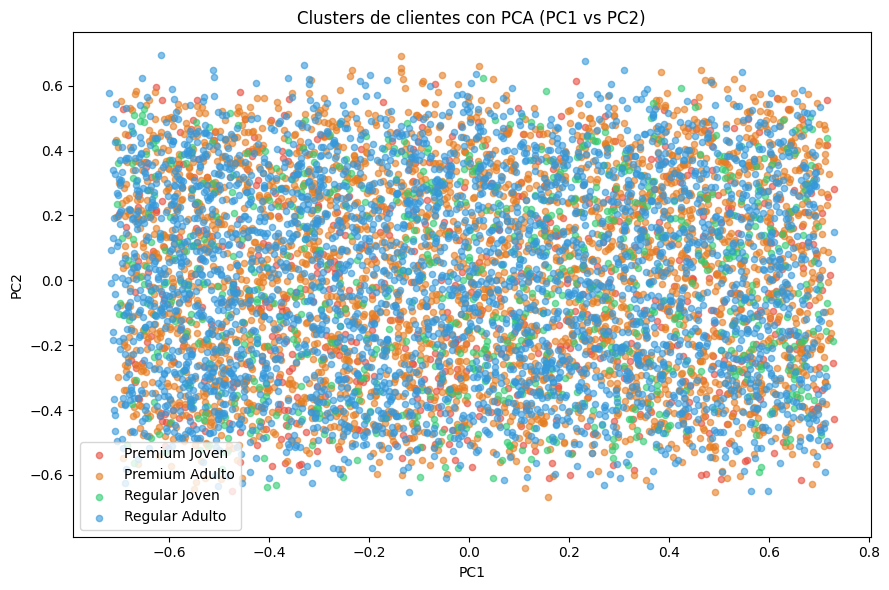

In [14]:
#scatter plot de los clusters identificados con pca
colores = {
    'Premium Joven':   '#e74c3c',
    'Premium Adulto':  '#e67e22',
    'Regular Joven':   '#2ecc71',
    'Regular Adulto':  '#3498db'
}

fig, ax = plt.subplots(figsize=(9, 6))
for segmento, color in colores.items():
    mask = df_final['segmento_cliente'] == segmento
    ax.scatter(df_final.loc[mask, 'PC1'], df_final.loc[mask, 'PC2'],
               c=color, label=segmento, alpha=0.6, s=20)

ax.set_title('Clusters de clientes con PCA (PC1 vs PC2)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()